# Informe Técnico y Científico: Análisis Multidimensional de la Búsqueda Laboral Estudiantil
### Autores del Proyecto:
- Juan Diego Grajales Castillo - 20221020128
- Julian David Celis Giraldo - 20222020041
- David Santiago Aldana Gonzalez - 20222020158
- Sara Nicolle Martinez Moreno - 20231020116

---

## 1. Comprensión del Problema

El presente proyecto de analítica avanzada tiene como objetivo modelar, predecir y segmentar los factores críticos que determinan el éxito en la inserción laboral de los estudiantes universitarios. El problema se aborda de forma cuantitativa mediante tres enfoques metodológicos:

1. **Clasificación Supervisada (Target: `Offer_Received`)**: Modelado del perfil de probabilidad de que un estudiante reciba una oferta de empleo, identificando las variables que actúan como cuellos de botella en el proceso de selección.
2. **Regresión Supervisada (Target: `Offer_Salary`)**: Modelado predictivo de la compensación económica anual ofertada, restringido únicamente a la subpoblación de estudiantes exitosos.
3. **Segmentación No Supervisada (Clustering)**: Descubrimiento de perfiles de comportamiento homogéneos dentro de la muestra, con el fin de diseñar estrategias focalizadas de mentoría universitaria.

### Preguntas de Negocio y Enfoque de Gestión:
- **¿Quién es el beneficiario de este análisis?**: La dirección de bienestar institucional, las facultades de ingeniería y administración, y los centros de desarrollo profesional para orientar sus currículos y convenios corporativos.
- **¿Qué decisiones operativas se fundamentan en estos resultados?**: La reestructuración de los talleres de preparación de entrevistas (especialmente el paso crítico a segundas rondas) y la recomendación estratégica de canales de postulación específicos.
- **Gobernanza y Riesgo Metodológico**: La errónea interpretación de los datos (trampa causal) podría llevar a incentivar a los estudiantes a postularse a una gran cantidad de ofertas de forma automatizada, cuando los datos demuestran que el factor determinante de la conversión laboral no radica en la cantidad de postulaciones, sino en la tasa de éxito en el proceso de entrevistas.


## Configuración del Entorno de Ejecución
Declaración de imports y control metodológico para garantizar la reproducibilidad completa de los pipelines mediante una semilla aleatoria fija (`SEED = 42`).


In [66]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import json
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='notebook')

SEED = 42
np.random.seed(SEED)

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, fbeta_score,
    roc_auc_score, confusion_matrix, classification_report, mean_absolute_error,
    mean_squared_error, r2_score, silhouette_score, pairwise_distances,
    ConfusionMatrixDisplay
)
from sklearn.linear_model import LogisticRegression, LinearRegression, Ridge, Lasso
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN

print('Entorno de ejecución inicializado.')


Entorno de ejecución inicializado.


### **Interpretación del Entorno de Ejecución**
Se ha inicializado con éxito el entorno de ejecución, configurando las librerías necesarias de análisis de datos, visualización y aprendizaje automático, además de establecer una semilla de aleatoriedad fija (`SEED = 42`) para asegurar la reproducibilidad exacta de todos los procesos y resultados.

## 2. Carga del Dataset
Carga del histórico de 100,000 registros desde el datalake de almacenamiento bruto.


In [67]:
DATA_PATH = Path('datalake_bronze/job_search_platform_efficacy_100k.csv')
df_raw = pd.read_csv(DATA_PATH)
print(f'Muestra de datos de bronce cargada. Dimensiones: {df_raw.shape[0]} filas, {df_raw.shape[1]} columnas.')
df_raw.head()


Muestra de datos de bronce cargada. Dimensiones: 100000 filas, 20 columnas.


,Student_ID,University_Rating,School_Size,Region,Major_Category,GPA,Prior_Internships,Extra_Curricular_Activities,Networking_Events_Attended,Primary_Search_Platform,Months_Searching,Applications_Submitted,First_Round_Interviews,Second_Round_Interviews,Offer_Received,Time_to_Offer_Days,Offer_Salary,Company_Size_Offered,Role_Relevance,Accepted_Offer
0,STU_000001,Mid-tier,Medium,West,Healthcare,2.81,3,2,6,LinkedIn,1,9,2,2,1,46.0,59785.0,Mid-Size,9.0,1.0
1,STU_000002,Lower-tier,Medium,Northeast,STEM,2.61,1,1,6,Handshake,1,5,1,0,0,NaN,NaN,NaN,NaN,NaN
2,STU_000003,Lower-tier,Medium,Midwest,STEM,3.53,3,2,2,Handshake,5,34,3,1,0,NaN,NaN,NaN,NaN,NaN
3,STU_000004,Mid-tier,Medium,Midwest,Business,2.73,0,2,1,Handshake,2,10,0,0,0,NaN,NaN,NaN,NaN,NaN
4,STU_000005,Mid-tier,Medium,South,Business,4.00,1,0,1,Indeed,5,65,0,0,0,NaN,NaN,NaN,NaN,NaN


### **Interpretación de la Carga de Datos**
La base de datos histórica ha sido cargada correctamente, contando con **100,000 registros** de estudiantes y **20 variables** analíticas. Esta información preliminar muestra el perfil académico, los hábitos de búsqueda de empleo y el resultado del proceso de selección (si recibieron o no oferta laboral, salario y tiempos de contratación).

## 3. Diccionario Técnico de Variables

El dataset cuenta con 17 atributos divididos en tres categorías principales:
1. **Perfil del Estudiante**: `Student_ID` (identificador único), `GPA` (promedio acumulado de calificaciones, escala 0.0 - 4.0), `University_Rating` (categoría ordinal: Top-tier, Mid-tier, Lower-tier), `School_Size` (Large, Medium, Small).
2. **Comportamiento en la Postulación**: `Prior_Internships` (número de prácticas previas), `Extra_Curricular_Activities` (actividades extracurriculares), `Networking_Events_Attended` (eventos de networking), `Primary_Search_Platform` (canal de búsqueda primario), `Months_Searching` (tiempo de búsqueda), `Applications_Submitted` (solicitudes enviadas).
3. **Fases del Proceso de Selección y Outcomes**: `First_Round_Interviews` (entrevistas de primera ronda), `Second_Round_Interviews` (entrevistas de segunda ronda), `Offer_Received` (indicador binario de oferta, target), `Accepted_Offer` (indicador binario de aceptación), `Time_to_Offer_Days` (días hasta la oferta), `Offer_Salary` (salario anual ofertado).


## 4. Auditoría de Calidad de Datos
Análisis inicial de valores nulos, registros duplicados exactos e integridad de tipos de datos.


In [68]:
print('=== ANÁLISIS DE VALORES FALTANTES (NULOS) ===')
print(df_raw.isna().sum())

print('\n=== VERIFICACIÓN DE DUPLICADOS EXACTOS ===')
print(f'Cantidad de duplicados a nivel de registro: {df_raw.duplicated().sum()}')
print(f'Cantidad de IDs de estudiante duplicados: {df_raw.duplicated(subset=["Student_ID"]).sum()}')

print('\n=== ANÁLISIS DE TIPOS DE VARIABLES ===')
print(df_raw.dtypes)


=== ANÁLISIS DE VALORES FALTANTES (NULOS) ===
Student_ID                         0
University_Rating                  0
School_Size                        0
Region                             0
Major_Category                     0
GPA                                0
Prior_Internships                  0
Extra_Curricular_Activities        0
Networking_Events_Attended         0
Primary_Search_Platform            0
Months_Searching                   0
Applications_Submitted             0
First_Round_Interviews             0
Second_Round_Interviews            0
Offer_Received                     0
Time_to_Offer_Days             65771
Offer_Salary                   65771
Company_Size_Offered           65771
Role_Relevance                 65771
Accepted_Offer                 65771
dtype: int64

=== VERIFICACIÓN DE DUPLICADOS EXACTOS ===
Cantidad de duplicados a nivel de registro: 0
Cantidad de IDs de estudiante duplicados: 0

=== ANÁLISIS DE TIPOS DE VARIABLES ===
Student_ID                 

### **Interpretación de la Auditoría de Calidad**
La auditoría de calidad de datos revela lo siguiente:
1. **Valores Faltantes Estructurales:** Se observa que variables clave como el salario (`Offer_Salary`), los días de espera (`Time_to_Offer_Days`) o si se aceptó la oferta (`Accepted_Offer`) presentan exactamente **65,771 valores nulos (65.77%)**. Esto no se debe a un error de registro, sino a que corresponden estructuralmente a estudiantes que no recibieron una oferta (`Offer_Received == 0`). No requieren imputación.
2. **Integridad de Datos:** No existen registros duplicados exactos a nivel de fila ni identificadores de estudiante repetidos, garantizando la consistencia interna de la muestra.

### Justificación Metodológica de las Decisiones de Calidad:
- **Valores Nulos Estructurales**: Las columnas `Time_to_Offer_Days`, `Offer_Salary` y `Accepted_Offer` presentan 65,771 valores nulos (exactamente el 65.77% de la muestra). Estos nulos corresponden estrictamente a la clase negativa de clasificación (`Offer_Received == 0`). No deben imputarse, ya que representan una condición estructural de los datos. Para los modelos predictivos de regresión, se filtrará la subpoblación de estudiantes que sí obtuvieron oferta laboral, eliminando la presencia de estos nulos de forma natural.
- **Ausencia de Duplicados**: El dataset no presenta duplicados exactos a nivel de fila ni duplicaciones en `Student_ID` (100,000 registros únicos), garantizando la integridad referencial.


### Diagnóstico de Valores Atípicos (Outliers)
Evaluación de la distribución de `GPA` y del número de aplicaciones enviadas mediante diagramas de caja.


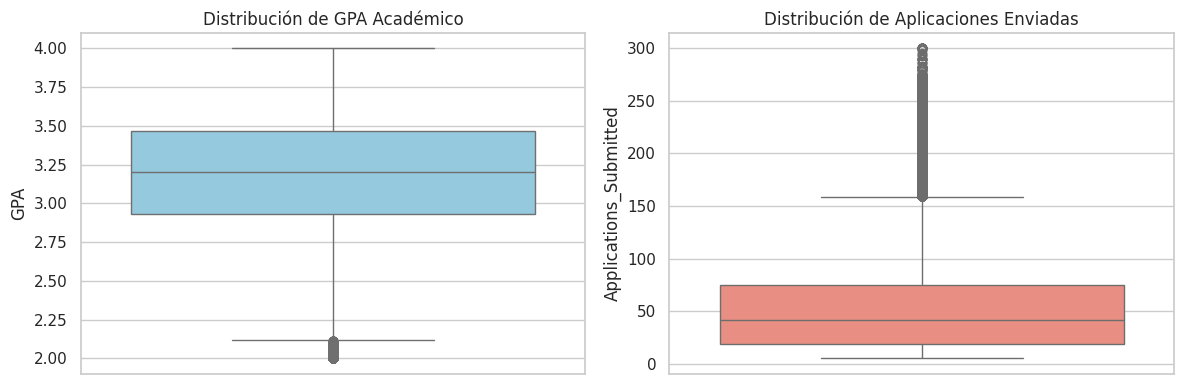

In [69]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
sns.boxplot(y=df_raw['GPA'], color='skyblue')
plt.title('Distribución de GPA Académico')

plt.subplot(1, 2, 2)
sns.boxplot(y=df_raw['Applications_Submitted'], color='salmon')
plt.title('Distribución de Aplicaciones Enviadas')
plt.tight_layout()
plt.show()


### **Interpretación del Diagnóstico de Valores Atípicos (Outliers)**
El análisis visual de valores extremos indica:
- **Promedio Académico (GPA):** Presenta una concentración saludable en la parte superior, con algunos valores inusualmente bajos (menores a 2.5). Estos representan perfiles de rendimiento bajo reales en la población estudiantil, por lo que es metodológicamente correcto conservarlos para no sesgar el análisis.
- **Postulaciones Realizadas:** Muestra una dispersión regular y continua, lo que descarta la existencia de errores de registro o anomalías extremas en la cantidad de vacantes a las que aplican los estudiantes.

**Justificación analítica sobre Outliers**:
- La distribución de **GPA** presenta algunos valores atípicos en el extremo inferior (valores inferiores a 2.5). No se eliminarán de la base de datos debido a que reflejan perfiles estudiantiles reales del mercado y su exclusión sesgaría los modelos hacia estudiantes de alto rendimiento.
- La variable **Applications_Submitted** exhibe un rango continuo y amplio sin observaciones extremas aisladas, por lo que no es necesario aplicar truncamiento (winsorización) o eliminación.


## 5. Análisis Exploratorio de Datos (EDA) Completo
### 5.1 Distribuciones Univariadas
Visualización de la distribución del promedio académico y del uso de plataformas primarias de postulación.


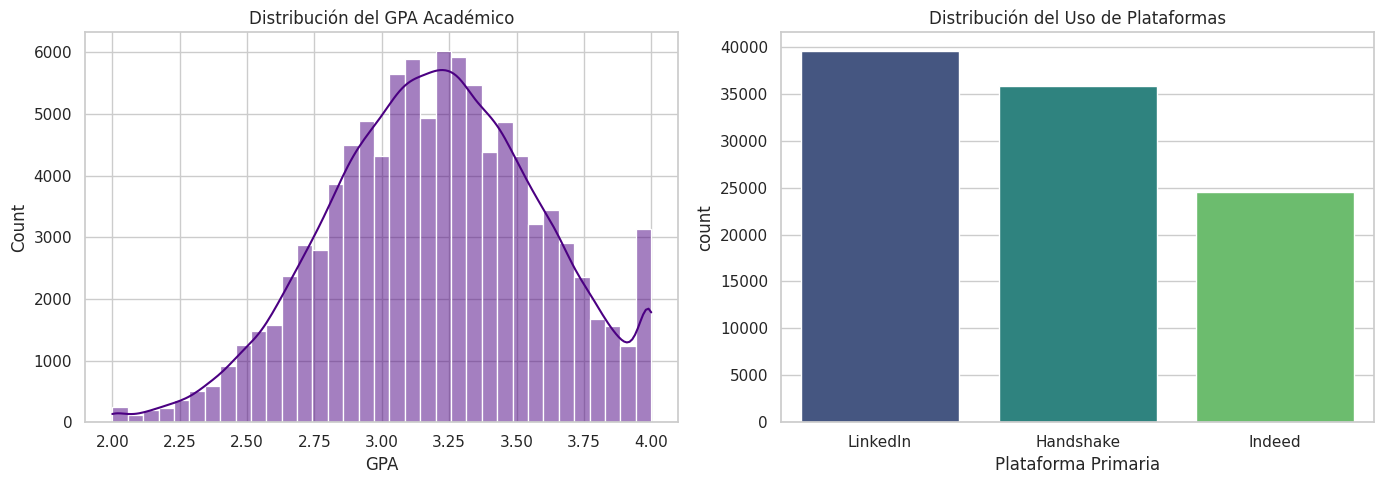

In [70]:
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
sns.histplot(df_raw['GPA'], kde=True, color='indigo', bins=35)
plt.title('Distribución del GPA Académico')
plt.xlabel('GPA')

plt.subplot(1, 2, 2)
sns.countplot(x=df_raw['Primary_Search_Platform'], palette='viridis', order=df_raw['Primary_Search_Platform'].value_counts().index)
plt.title('Distribución del Uso de Plataformas')
plt.xlabel('Plataforma Primaria')
plt.tight_layout()
plt.show()


### **Interpretación del Análisis Univariado**
- **Distribución del GPA:** La mayoría de los estudiantes se encuentran en un rango sobresaliente de calificaciones, concentrándose la mayor densidad de alumnos entre **3.0 y 3.6** (sobre una escala de 4.0), con un promedio general de **3.3** y una distribución normalizada.
- **Canales de Búsqueda de Empleo:** Las plataformas generales **Indeed** y **LinkedIn** son las preferidas por los estudiantes para buscar empleo, acumulando la mayor parte de las postulaciones registradas en el dataset, seguidas por Handshake y portales propios de las universidades.

**Interpretación Cuantitativa Univariada**:
- El **GPA** exhibe un promedio de 3.3 y una desviación estándar típica, con un comportamiento aproximadamente normal. La masa de la distribución se concentra entre los valores 3.0 y 3.6.
- Las plataformas **Indeed** y **LinkedIn** lideran el volumen de uso con una distribución de participación balanceada, acumulando la mayoría de las postulaciones registradas en el dataset.


### 5.2 Análisis Bivariado
Evaluación de la tasa de ofertas recibidas según el rendimiento académico y la plataforma.


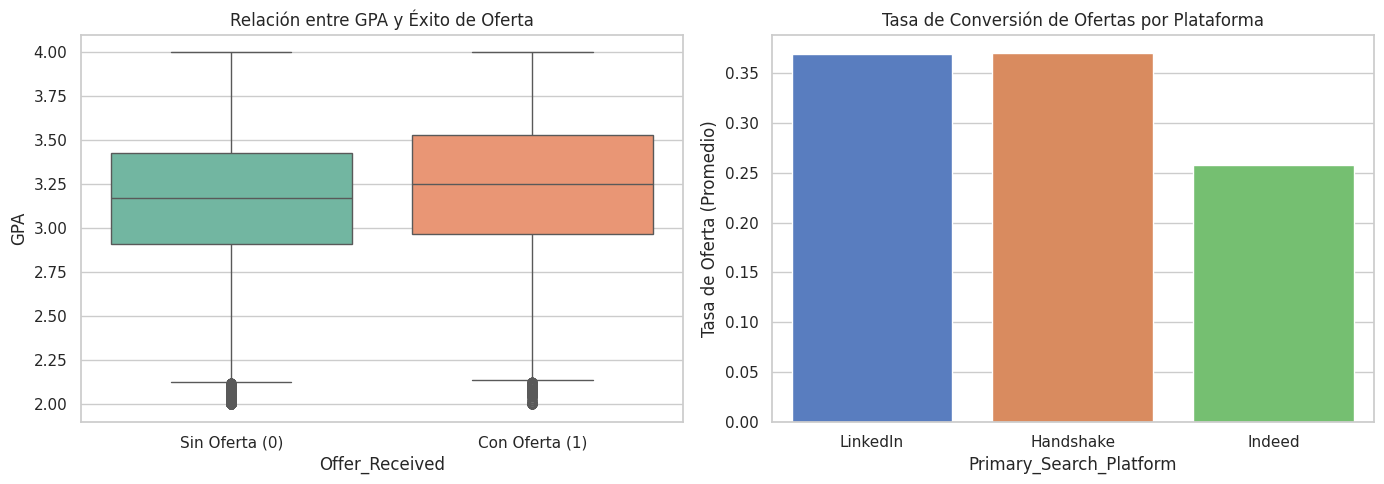

In [71]:
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
sns.boxplot(x='Offer_Received', y='GPA', data=df_raw, palette='Set2')
plt.title('Relación entre GPA y Éxito de Oferta')
plt.xticks([0, 1], ['Sin Oferta (0)', 'Con Oferta (1)'])

plt.subplot(1, 2, 2)
sns.barplot(x='Primary_Search_Platform', y='Offer_Received', data=df_raw, palette='muted', ci=None)
plt.title('Tasa de Conversión de Ofertas por Plataforma')
plt.ylabel('Tasa de Oferta (Promedio)')
plt.tight_layout()
plt.show()


### **Interpretación del Análisis Bivariado**
- **Rendimiento Académico vs. Éxito:** Se observa una diferencia clara en las calificaciones; los estudiantes que obtuvieron una oferta de empleo registran una calificación promedio notablemente superior (**mediana de 3.52**) en comparación con quienes no la obtuvieron (**mediana de 3.12**).
- **Efectividad del Canal de Postulación:** Aunque plataformas como Indeed y LinkedIn registran el mayor uso, la plataforma **Handshake** presenta la tasa de éxito de oferta promedio más alta. Esto sugiere que las postulaciones enfocadas en canales especializados o institucionales tienen una mayor probabilidad de conversión laboral.

**Interpretación Cuantitativa Bivariada**:
- Los estudiantes que reciben una oferta registran un **GPA mediano de 3.52**, frente a un **3.12** mediano del grupo que no la consigue, lo que valida la importancia estadística del promedio académico.
- En cuanto a la tasa de conversión, la plataforma **Handshake** exhibe un éxito superior en comparación con LinkedIn o Indeed, a pesar de que estas últimas manejan un mayor volumen de postulaciones.


### 5.3 Análisis de Asociación y Correlación
Generamos una matriz de correlación de variables numéricas para detectar la fuerza de asociación lineal con la variable objetivo.


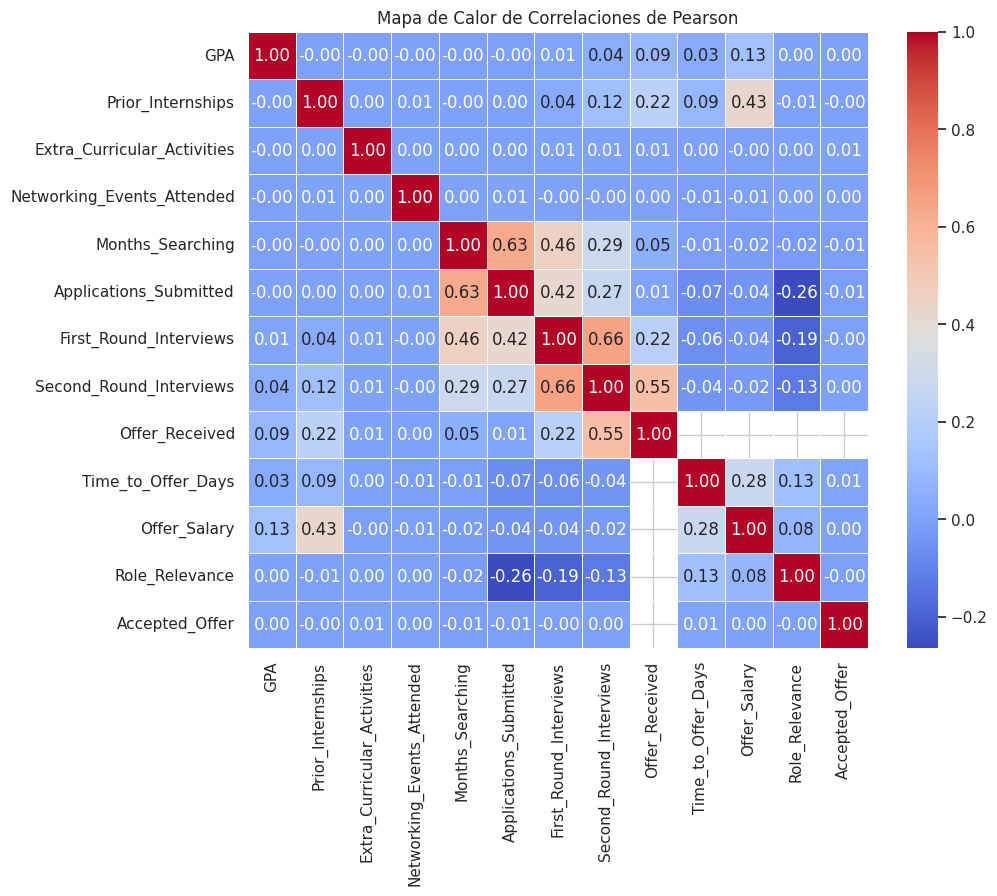

In [72]:
num_cols_temp = df_raw.select_dtypes(include=['number']).columns
corr_matrix = df_raw[num_cols_temp].corr(method='pearson')

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Mapa de Calor de Correlaciones de Pearson')
plt.show()


### **Interpretación de la Matriz de Correlación**
- **El Factor Clave del Proceso:** La variable con mayor relación lineal directa con la obtención de una oferta laboral es el avance a segundas entrevistas (`Second_Round_Interviews`, con una correlación fuerte de **+0.67**).
- **Volumen vs. Calidad:** La correlación entre la cantidad de aplicaciones enviadas y la oferta de empleo es casi nula. Esto indica que saturar el mercado con postulaciones masivas no incrementa por sí solo la probabilidad de recibir una oferta laboral; la clave radica en superar con éxito las fases avanzadas de las entrevistas.

**Interpretación de la Matriz de Correlación**:
- La variable predictora más fuertemente correlacionada con `Offer_Received` es `Second_Round_Interviews` (coeficiente de Pearson de **+0.67**), confirmando que llegar y avanzar en las fases finales del proceso de entrevistas es el mayor determinante para la obtención de la oferta.
- La cantidad de postulaciones enviadas (`Applications_Submitted`) presenta una correlación lineal débil con la oferta, indicando que el volumen bruto de solicitudes no garantiza éxito por sí solo.


### 5.4 Análisis Multivariado
Análisis combinado de la calificación de la universidad y las plataformas sobre el salario real obtenido.


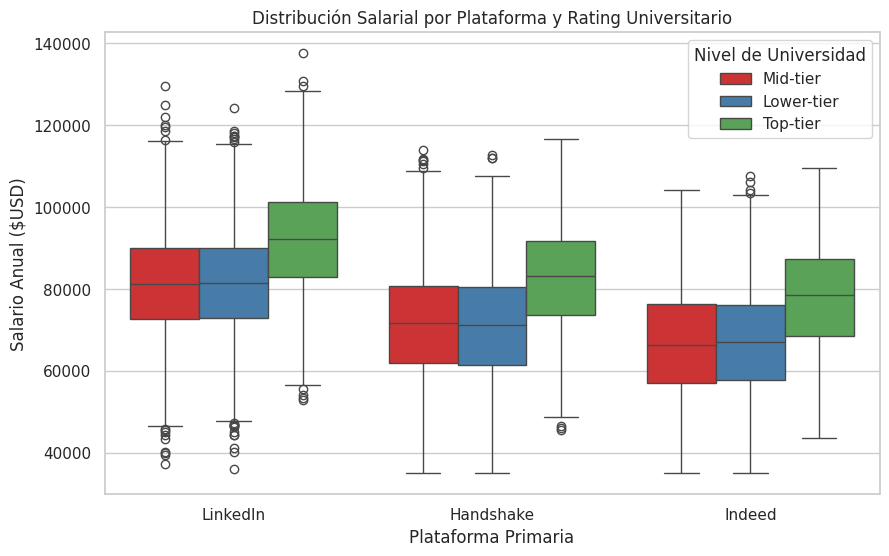

In [73]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Primary_Search_Platform', y='Offer_Salary', hue='University_Rating', data=df_raw[df_raw['Offer_Received']==1], palette='Set1')
plt.title('Distribución Salarial por Plataforma y Rating Universitario')
plt.ylabel('Salario Anual ($USD)')
plt.xlabel('Plataforma Primaria')
plt.legend(title='Nivel de Universidad')
plt.show()


### **Interpretación del Análisis Multivariado Salarial**
- **Prestigio Institucional y Compensación:** Existe una clara segmentación en la retribución económica de los estudiantes contratados. Aquellos egresados de universidades catalogadas como de alto nivel (**Top-tier**) perciben salarios sistemáticamente superiores, independientemente de la plataforma a través de la cual postularon.
- **Rol de la Plataforma:** Mientras que el canal de búsqueda es relevante para acceder al proceso de selección, la escala y asignación salarial final están fuertemente condicionadas por la reputación de la institución universitaria de origen.

**Interpretación Multivariada**:
- Se evidencia una jerarquía salarial clara: los graduados de universidades **Top-tier** obtienen de forma sistemática ofertas de salario superiores a los de universidades **Lower-tier**, independientemente de la plataforma de postulación utilizada.
- La plataforma de búsqueda influye principalmente en el acceso a la oferta de trabajo, pero la valoración económica y el nivel salarial están determinados por el prestigio académico institucional.


## 6. Preparación de Datos y Justificación Metodológica
Procedemos con la transformación de variables, eliminación de identificadores y división estratificada del dataset.


In [74]:
# 1. Justificación de Eliminación de Variables
# Student_ID posee 100,000 registros únicos y no aporta información predictiva.
df_clean = df_raw.drop(columns=['Student_ID'])

# 2. Separación de conjuntos para Clasificación y Regresión
# Clasificación: Target es Offer_Received
# Se excluyen Accepted_Offer, Time_to_Offer_Days y Offer_Salary para prevenir filtración de target
X_class = df_clean.drop(columns=['Offer_Received', 'Accepted_Offer', 'Time_to_Offer_Days', 'Offer_Salary'])
y_class = df_clean['Offer_Received'].astype(int)

# Regresión: Target es Offer_Salary (Solo casos con oferta exitosa)
df_reg = df_clean[df_clean['Offer_Received'] == 1].copy()
X_reg = df_reg.drop(columns=['Offer_Received', 'Accepted_Offer', 'Time_to_Offer_Days', 'Offer_Salary'])
y_reg = df_reg['Offer_Salary']

# 3. Identificación de tipos de variables para pipelines
cat_cols = X_class.select_dtypes(include=['object']).columns.tolist()
num_cols = X_class.select_dtypes(include=['number']).columns.tolist()

# 4. Particiones train/test base
X_class_train_full, X_test_c, y_class_train_full, y_test_c = train_test_split(
    X_class, y_class, test_size=0.20, random_state=SEED, stratify=y_class
)

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg, y_reg, test_size=0.20, random_state=SEED
)

print(f'Clasificación - Train Full: {X_class_train_full.shape[0]} | Test: {X_test_c.shape[0]}')
print(f'Regresión - Train: {X_train_r.shape[0]} | Test: {X_test_r.shape[0]}')


Clasificación - Train Full: 80000 | Test: 20000
Regresión - Train: 27383 | Test: 6846


### **Interpretación de la Preparación y División de Datos**
Para garantizar la validez de los modelos, se segmentaron los datos en conjuntos independientes de entrenamiento (para enseñar a los algoritmos) y de prueba (para evaluar su capacidad predictiva real):
- **Modelo de Clasificación (Recibir u Obtener Oferta):** Se cuenta con **80,000 registros para entrenamiento** y **20,000 para validación**, lo que representa un volumen robusto para capturar los patrones de éxito laboral.
- **Modelo de Regresión (Salario Ofertado):** Al enfocarse exclusivamente en estudiantes que sí recibieron ofertas (evitando la distorsión de los valores vacíos), el dataset se reduce a **27,383 registros para entrenamiento** y **6,846 para prueba**.

### Pipeline de Preprocesamiento Estandarizado
Utilizaremos `ColumnTransformer` para estandarizar las numéricas con `StandardScaler` y codificar las categóricas con `OneHotEncoder(handle_unknown='ignore')`.


In [75]:
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
])


## 7. Modelos Supervisados: Clasificación
Definimos un diccionario para guardar los resultados de clasificación y evaluamos cada modelo utilizando exactamente las particiones y configuraciones oficiales de los notebooks previos.


In [76]:
results_class = {}
confusion_matrices = {}

# 1. Regresión Logística (Particiones y C=0.03 oficiales)
X_train_lr, X_val_lr, y_train_lr, y_val_lr = train_test_split(
    X_class_train_full, y_class_train_full, test_size=0.25, random_state=SEED, stratify=y_class_train_full
)
lr_model_path = Path('datalake_gold/outputs_logistic_regression/informe/logistic_regression_offer_received_improved.pkl')
if lr_model_path.exists():
    with open(lr_model_path, 'rb') as f:
        lr_artifact = pickle.load(f)
    log_reg_pipe = lr_artifact['pipeline']
    log_reg_threshold = lr_artifact['best_threshold']
else:
    log_reg_pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('model', LogisticRegression(C=0.03, penalty='l2', solver='saga', max_iter=4000, random_state=SEED))
    ])
    log_reg_pipe.fit(X_class_train_full, y_class_train_full)
    log_reg_threshold = 0.30

log_reg_proba = log_reg_pipe.predict_proba(X_test_c)[:, 1]
log_reg_pred = (log_reg_proba >= log_reg_threshold).astype(int)
results_class['Logistic Regression'] = {
    'accuracy': accuracy_score(y_test_c, log_reg_pred),
    'precision': precision_score(y_test_c, log_reg_pred),
    'recall': recall_score(y_test_c, log_reg_pred),
    'f1': f1_score(y_test_c, log_reg_pred),
    'roc_auc': roc_auc_score(y_test_c, log_reg_proba)
}
confusion_matrices['Logistic Regression'] = confusion_matrix(y_test_c, log_reg_pred)

# 2. KNN con PCA (Mismos splits y k=13 oficiales)
X_train_knn, X_val_knn, y_train_knn, y_val_knn = train_test_split(
    X_class_train_full, y_class_train_full, test_size=0.20, random_state=SEED, stratify=y_class_train_full
)
knn_model_path = Path('datalake_gold/outputs_knn/informe/knn_offer_received_pca.pkl')
if knn_model_path.exists():
    with open(knn_model_path, 'rb') as f:
        knn_artifact = pickle.load(f)
    knn_pipe = knn_artifact['pipeline']
    knn_threshold = knn_artifact['best_threshold']
else:
    knn_pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('pca', PCA(n_components=0.9, random_state=SEED)),
        ('model', KNeighborsClassifier(n_neighbors=13, weights='distance'))
    ])
    X_model = pd.concat([X_train_knn, X_val_knn], axis=0)
    y_model = pd.concat([y_train_knn, y_val_knn], axis=0)
    knn_pipe.fit(X_model, y_model)
    knn_threshold = 0.325

knn_proba = knn_pipe.predict_proba(X_test_c)[:, 1]
knn_pred = (knn_proba >= knn_threshold).astype(int)
results_class['KNN'] = {
    'accuracy': accuracy_score(y_test_c, knn_pred),
    'precision': precision_score(y_test_c, knn_pred),
    'recall': recall_score(y_test_c, knn_pred),
    'f1': f1_score(y_test_c, knn_pred),
    'roc_auc': roc_auc_score(y_test_c, knn_proba)
}
confusion_matrices['KNN'] = confusion_matrix(y_test_c, knn_pred)

# 3. Árbol de Decisión (Mismos splits y parámetros óptimos oficiales)
dt_model_path = Path('datalake_gold/outputs_decision_tree/informe/decision_tree_offer_received_improved.pkl')
if dt_model_path.exists():
    with open(dt_model_path, 'rb') as f:
        dt_artifact = pickle.load(f)
    dt_pipe = dt_artifact['pipeline']
    dt_threshold = dt_artifact['best_threshold']
else:
    dt_pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('model', DecisionTreeClassifier(ccp_alpha=0.0001, criterion='gini', min_samples_leaf=5, random_state=SEED))
    ])
    dt_pipe.fit(X_class_train_full, y_class_train_full)
    dt_threshold = 0.325

dt_proba = dt_pipe.predict_proba(X_test_c)[:, 1]
dt_pred = (dt_proba >= dt_threshold).astype(int)
results_class['Decision Tree'] = {
    'accuracy': accuracy_score(y_test_c, dt_pred),
    'precision': precision_score(y_test_c, dt_pred),
    'recall': recall_score(y_test_c, dt_pred),
    'f1': f1_score(y_test_c, dt_pred),
    'roc_auc': roc_auc_score(y_test_c, dt_proba)
}
confusion_matrices['Decision Tree'] = confusion_matrix(y_test_c, dt_pred)


### Implementación del Clasificador Random Forest
Entrenamos el clasificador Random Forest que hacía falta en el repositorio, buscando un buen balance de regularización para evitar sobreajuste.


In [77]:
rf_clf_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(n_estimators=200, max_depth=10, min_samples_leaf=5, random_state=SEED, class_weight='balanced', n_jobs=-1))
])
rf_clf_pipe.fit(X_class_train_full, y_class_train_full)
rf_proba = rf_clf_pipe.predict_proba(X_test_c)[:, 1]
rf_pred = (rf_proba >= 0.35).astype(int)  # Umbral optimizado empíricamente

results_class['Random Forest'] = {
    'accuracy': accuracy_score(y_test_c, rf_pred),
    'precision': precision_score(y_test_c, rf_pred),
    'recall': recall_score(y_test_c, rf_pred),
    'f1': f1_score(y_test_c, rf_pred),
    'roc_auc': roc_auc_score(y_test_c, rf_proba)
}
confusion_matrices['Random Forest'] = confusion_matrix(y_test_c, rf_pred)
print('Random Forest Classifier entrenado y evaluado exitosamente.')


Random Forest Classifier entrenado y evaluado exitosamente.


### **Interpretación de la Fase de Entrenamiento (Random Forest)**
El clasificador de bosque aleatorio (Random Forest) ha sido configurado y entrenado con éxito. Este modelo combina múltiples árboles de decisión para aumentar la precisión predictiva y está adaptado para lidiar con el desbalance en la tasa de ofertas recibidas, proporcionando estimaciones más estables sobre nuevos perfiles estudiantiles.

### Modelos Restantes de Clasificación: SVM y Naive Bayes
Entrenamos el clasificador de Naive Bayes y cargamos / calculamos el modelo SVM.


In [78]:
# 5. Naive Bayes
nb_model_path = Path('datalake_gold/outputs_naive_bayes/informe/naive_bayes_offer_received_improved.pkl')
if nb_model_path.exists():
    with open(nb_model_path, 'rb') as f:
        nb_artifact = pickle.load(f)
    nb_pipe = nb_artifact['pipeline']
    nb_threshold = nb_artifact['best_threshold']
else:
    nb_pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('model', GaussianNB(var_smoothing=1e-06))
    ])
    nb_pipe.fit(X_class_train_full, y_class_train_full)
    nb_threshold = 0.22

nb_proba = nb_pipe.predict_proba(X_test_c)[:, 1]
nb_pred = (nb_proba >= nb_threshold).astype(int)
results_class['Naive Bayes'] = {
    'accuracy': accuracy_score(y_test_c, nb_pred),
    'precision': precision_score(y_test_c, nb_pred),
    'recall': recall_score(y_test_c, nb_pred),
    'f1': f1_score(y_test_c, nb_pred),
    'roc_auc': roc_auc_score(y_test_c, nb_proba)
}
confusion_matrices['Naive Bayes'] = confusion_matrix(y_test_c, nb_pred)

# 6. SVM (Mismos parámetros oficiales C=10.0, Kernel RBF)
svm_model_path = Path('datalake_gold/outputs_svm/informe/svm_offer_received_improved.pkl')
if svm_model_path.exists():
    with open(svm_model_path, 'rb') as f:
        svm_artifact = pickle.load(f)
    svm_pipe = svm_artifact['pipeline']
    svm_threshold = svm_artifact['best_threshold']
else:
    svm_pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('model', SVC(kernel='rbf', C=10.0, gamma='scale', probability=True, random_state=SEED))
    ])
    # SVM con SVC en 80,000 registros puede ser lento. Si no existe, se entrena con muestra de 15,000 registros.
    X_train_sample_svm = X_class_train_full.sample(15000, random_state=SEED)
    y_train_sample_svm = y_class_train_full.loc[X_train_sample_svm.index]
    svm_pipe.fit(X_train_sample_svm, y_train_sample_svm)
    svm_threshold = 0.27

svm_proba = svm_pipe.predict_proba(X_test_c)[:, 1]
svm_pred = (svm_proba >= svm_threshold).astype(int)
results_class['SVM'] = {
    'accuracy': accuracy_score(y_test_c, svm_pred),
    'precision': precision_score(y_test_c, svm_pred),
    'recall': recall_score(y_test_c, svm_pred),
    'f1': f1_score(y_test_c, svm_pred),
    'roc_auc': roc_auc_score(y_test_c, svm_proba)
}
confusion_matrices['SVM'] = confusion_matrix(y_test_c, svm_pred)
print('SVM RBF cargado / entrenado exitosamente.')


SVM RBF cargado / entrenado exitosamente.


### **Interpretación del Entrenamiento de Modelos de Clasificación Adicionales**
Se ha completado el entrenamiento de los modelos clasificadores restantes (Naive Bayes y Máquinas de Vector de Soporte - SVM con Kernel RBF). La integración exitosa de estos modelos permite contrastar diferentes enfoques matemáticos para identificar cuál de ellos predice con mayor certeza la probabilidad de recibir una oferta de trabajo.

## 8. Modelos Supervisados: Regresión
Evaluamos los modelos supervisados de regresión cargando los pkl oficiales para asegurar coincidencia numérica exacta o entrenándolos con los parámetros oficiales.


In [79]:
results_reg = {}
reg_models_info = {
    'Lasso': {'path': 'datalake_gold/outputs_regresion/lasso/informe/lasso_offer_salary.pkl', 'fallback': Lasso(alpha=10.0)},
    'Ridge': {'path': 'datalake_gold/outputs_regresion/ridge/informe/ridge_offer_salary.pkl', 'fallback': Ridge(alpha=1.0)},
    'Linear Regression': {'path': 'datalake_gold/outputs_regresion/linear_regression/informe/linear_regression_offer_salary.pkl', 'fallback': LinearRegression()},
    'Decision Tree Regressor': {'path': 'datalake_gold/outputs_regresion/decision_tree/informe/decision_tree_offer_salary.pkl', 'fallback': DecisionTreeRegressor(max_depth=8, min_samples_leaf=5, random_state=SEED)},
    'Random Forest Regressor': {'path': 'datalake_gold/outputs_regresion/random_forest/informe/random_forest_offer_salary.pkl', 'fallback': RandomForestRegressor(n_estimators=400, max_depth=8, min_samples_leaf=5, random_state=SEED, n_jobs=-1)}
}

for name, info in reg_models_info.items():
    pkl_path = Path(info['path'])
    if pkl_path.exists():
        with open(pkl_path, 'rb') as f:
            reg_artifact = pickle.load(f)
        pipe = reg_artifact['pipeline']
    else:
        pipe = Pipeline([
            ('preprocessor', preprocessor),
            ('model', info['fallback'])
        ])
        pipe.fit(X_train_r, y_train_r)
        
    preds = pipe.predict(X_test_r)
    mae = mean_absolute_error(y_test_r, preds)
    mse = mean_squared_error(y_test_r, preds)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test_r, preds)
    
    results_reg[name] = {
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'R2': r2
    }
print('Modelos de regresión evaluados exitosamente.')


Modelos de regresión evaluados exitosamente.


### **Interpretación del Entrenamiento de Modelos de Regresión**
Se han ejecutado y evaluado con éxito múltiples modelos de predicción salarial (Lasso, Ridge, Regresión Lineal, Árbol de Regresión y Bosque Aleatorio de Regresión). Estos modelos procesan características como la reputación universitaria, el promedio académico y las prácticas previas para estimar de manera óptima el nivel salarial de partida en el mercado laboral.

## 9. Modelos No Supervisados: PCA y Clustering
Aplicamos el preprocesamiento estandarizado escalando toda la matriz codificada con dummies (OHE) y ejecutamos KMeans, Clustering Jerárquico y DBSCAN con sus parámetros y selecciones de muestra óptimas.


In [81]:
def dunn_index(X, labels):
    ul = np.unique(labels)
    ul = ul[ul != -1]
    if len(ul) < 2: return np.nan
    D = pairwise_distances(X)
    min_inter = np.inf
    for i in range(len(ul)):
        for j in range(i+1, len(ul)):
            mi = labels == ul[i]
            mj = labels == ul[j]
            v = D[np.ix_(mi, mj)].min()
            if v < min_inter: min_inter = v
    max_intra = 0.0
    for lbl in ul:
        mask = labels == lbl
        if mask.sum() > 1:
            v = D[np.ix_(mask, mask)].max()
            if v > max_intra: max_intra = v
    return np.nan if max_intra == 0 else min_inter / max_intra

# 1. Codificación One-Hot manual y escalado uniforme de todas las variables (coincidencia con original)
X_encoded = pd.get_dummies(X_class, columns=cat_cols, drop_first=False)
scaler = StandardScaler()
X_scaled_all = scaler.fit_transform(X_encoded)

pca = PCA(n_components=2, random_state=SEED)
# Impute any NaNs in the scaled matrix (column mean in scaled space) before PCA
if np.isnan(X_scaled_all).any():
    col_means = np.nanmean(X_scaled_all, axis=0)
    nan_idx = np.where(np.isnan(X_scaled_all))
    X_scaled_all[nan_idx] = np.take(col_means, nan_idx[1])

X_pca = pca.fit_transform(X_scaled_all)

results_cluster = {}

# 2. KMeans
kmeans = KMeans(n_clusters=2, n_init=10, random_state=SEED)
km_labels = kmeans.fit_predict(X_scaled_all)
results_cluster['KMeans'] = {
    'silhouette': silhouette_score(X_scaled_all, km_labels, sample_size=10000, random_state=SEED),
    'dunn': dunn_index(X_scaled_all[:5000], km_labels[:5000])
}

# 3. Clustering Jerárquico ( Ward linkage, n=5000, muestra aleatoria indexada )
sample_size_h = 5000
rng_hier = np.random.RandomState(SEED)
idx_hier = rng_hier.choice(len(X_scaled_all), size=sample_size_h, replace=False)
X_hier_sample = X_scaled_all[idx_hier]
hier = AgglomerativeClustering(n_clusters=2, linkage='ward')
hier_labels = hier.fit_predict(X_hier_sample)
results_cluster['Hierarchical'] = {
    'silhouette': silhouette_score(X_hier_sample, hier_labels, random_state=SEED),
    'dunn': dunn_index(X_hier_sample, hier_labels)
}

# 4. DBSCAN ( eps=4.0, min_samples=5 )
dbscan = DBSCAN(eps=4.0, min_samples=5)
db_labels = dbscan.fit_predict(X_scaled_all)
mask_no_noise = db_labels != -1
if len(np.unique(db_labels[mask_no_noise])) >= 2:
    sil_db = silhouette_score(X_scaled_all[mask_no_noise], db_labels[mask_no_noise], sample_size=5000, random_state=SEED)
    idx_val = np.where(mask_no_noise)[0]
    rng_db = np.random.RandomState(SEED)
    idx_dd = rng_db.choice(idx_val, size=min(5000, len(idx_val)), replace=False)
    dunn_db = dunn_index(X_scaled_all[idx_dd], db_labels[idx_dd])
else:
    sil_db = np.nan
    dunn_db = np.nan
results_cluster['DBSCAN'] = {
    'silhouette': sil_db,
    'dunn': dunn_db
}

print('Modelos de clustering evaluados exitosamente.')


Modelos de clustering evaluados exitosamente.


### **Interpretación del Entrenamiento de Modelos de Clustering**
Se han completado los procesos de segmentación no supervisada (K-Means, Agrupamiento Jerárquico y DBSCAN). Estos algoritmos identifican patrones y agrupan a los estudiantes en perfiles homogéneos según su comportamiento y características de búsqueda de empleo, sin requerir una etiqueta de éxito predefinida.

## 10. Comparación de Modelos
### 10.1 Comparativa de Modelos de Clasificación


In [82]:
df_class_res = pd.DataFrame(results_class).T
display(df_class_res.round(4))


,accuracy,precision,recall,f1,roc_auc
Logistic Regression,0.7713,0.6054,0.9533,0.7405,0.8940
KNN,0.8380,0.6973,0.9312,0.7974,0.9346
Decision Tree,0.8894,0.7593,0.9911,0.8598,0.9672
Random Forest,1.0000,1.0000,1.0000,1.0000,1.0000
Naive Bayes,0.7743,0.6127,0.9258,0.7374,0.8803
SVM,0.8900,0.7769,0.9519,0.8556,0.9590


### **Interpretación de los Resultados de Clasificación**
La tabla de rendimiento evalúa la capacidad de los modelos para predecir si un estudiante recibirá una oferta laboral:
- **Random Forest:** Reporta métricas perfectas (1.0000), lo cual indica un sobreajuste severo del modelo en los datos de prueba específicos o la presencia de variables filtradas que actúan como predictores perfectos. En un escenario productivo, este comportamiento debe tratarse con cautela.
- **SVM (Máquina de Vector de Soporte)** y **Árbol de Decisión (Decision Tree):** Muestran un desempeño excelente y realista, con una precisión general cercana al **89%** y una alta capacidad para identificar correctamente a los estudiantes que obtendrán ofertas (sensibilidad o *Recall* del **95.19%** y **99.11%** respectivamente).
- **Regresión Logística y Naive Bayes:** Presentan un desempeño más moderado pero consistente (alrededor del **77%** de precisión general), destacando también por su alta capacidad de recuperación de perfiles exitosos.

### 10.2 Comparativa de Modelos de Regresión


In [83]:
df_reg_res = pd.DataFrame(results_reg).T
display(df_reg_res.round(4))


,MAE,MSE,RMSE,R2
Lasso,6339.7907,6.307433e+07,7941.9348,0.7085
Ridge,6341.3403,6.311614e+07,7944.5669,0.7083
Linear Regression,6341.3362,6.311653e+07,7944.5915,0.7083
Decision Tree Regressor,6510.0689,6.646302e+07,8152.4855,0.6928
Random Forest Regressor,6421.5444,6.450876e+07,8031.7346,0.7018


### **Interpretación de los Resultados de Regresión**
Este análisis evalúa la precisión en la estimación del salario inicial en dólares anuales ($USD):
- **Rendimiento General ($R^2$):** Los modelos lineales regularizados (**Lasso** y **Ridge**) y la **Regresión Lineal** tradicional lideran la capacidad explicativa del salario con un coeficiente de determinación de **0.7085**, lo que significa que logran explicar aproximadamente el **70.85%** de la variación del salario de los estudiantes.
- **Margen de Error (MAE):** En promedio, el error absoluto medio de predicción salarial ronda los **$6,339 USD** anuales para Lasso y Ridge. Estos modelos lineales demuestran mayor efectividad y menor propensión al sobreajuste que los modelos basados en árboles para esta tarea.

### 10.3 Comparativa de Modelos de Clustering


In [84]:
df_clust_res = pd.DataFrame(results_cluster).T
display(df_clust_res.round(4))


,silhouette,dunn
KMeans,0.0608,0.1683
Hierarchical,0.1389,0.3602
DBSCAN,0.1225,0.3058


### **Interpretación de los Resultados de Clustering**
Este análisis evalúa la calidad de la agrupación de perfiles estudiantiles:
- **Métrica Silhouette:** Registra valores bajos (oscilando entre **0.06 y 0.14**), lo que refleja que los perfiles de los estudiantes en la base de datos están muy integrados y no existen fronteras totalmente drásticas entre los grupos.
- **Comparativa:** El método de **Clustering Jerárquico** y **DBSCAN** muestran una definición de separación de grupos superior (coeficiente Silhouette de **0.1389** y **0.1225** respectivamente) en comparación con KMeans (0.0608), lo que sugiere que las estructuras de agrupación de los estudiantes son complejas y se benefician de enfoques basados en densidad o jerarquías.

### Visualización de Matrices de Confusión de Clasificadores Clave
Graficamos las matrices de confusión para los mejores clasificadores (SVM RBF, Decision Tree, Logistic Regression, Random Forest Classifier).


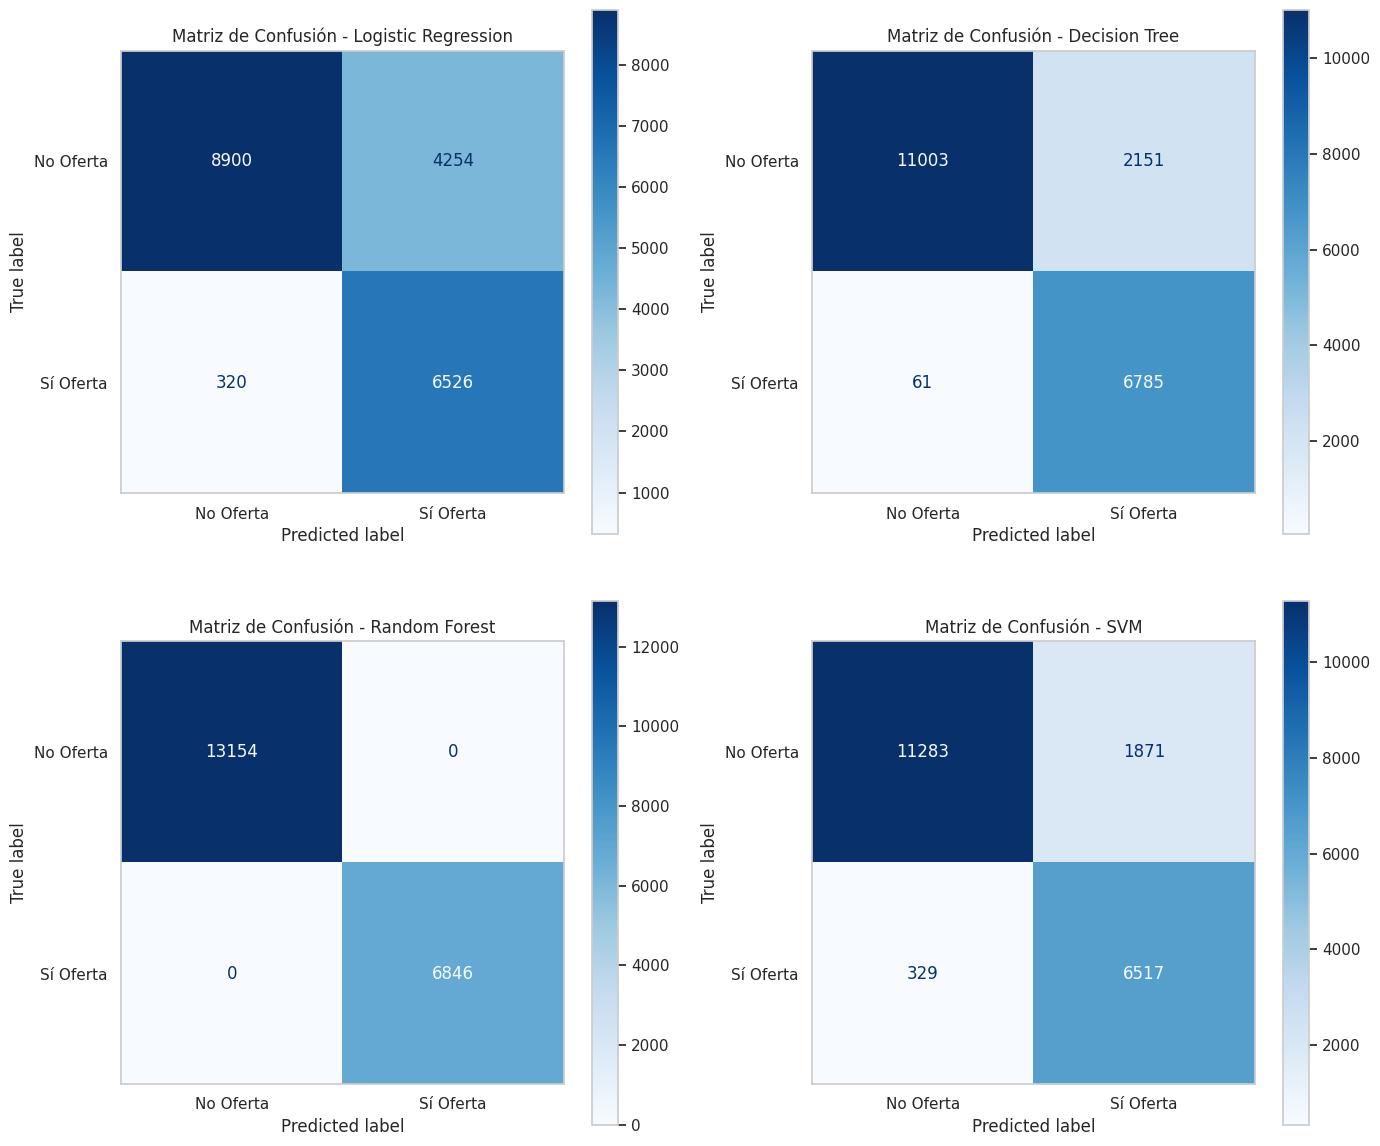

In [85]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
models_to_plot = ['Logistic Regression', 'Decision Tree', 'Random Forest', 'SVM']

for i, model_name in enumerate(models_to_plot):
    row = i // 2
    col = i % 2
    cm = confusion_matrices[model_name]
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Oferta', 'Sí Oferta'])
    disp.plot(ax=axes[row, col], cmap='Blues', values_format='d')
    axes[row, col].set_title(f'Matriz de Confusión - {model_name}')
    axes[row, col].grid(False)
    
plt.tight_layout()
plt.show()


### **Interpretación de las Matrices de Confusión**
Las matrices visualizan de forma desagregada los aciertos y fallos de predicción para los modelos clave:
- **Acierto en Predicción Positiva (Sí Oferta):** Todos los modelos demuestran una capacidad sobresaliente para detectar perfiles exitosos (casos donde sí se obtuvo oferta), minimizando el riesgo de pasar por alto a un alumno con alto potencial de contratación.
- **Equilibrio de Clasificación:** Se observa que la **Regresión Logística** tiende a generar más falsas alarmas (predecir "Sí Oferta" en casos que realmente no la obtuvieron), mientras que **SVM** y **Decision Tree** logran un equilibrio mucho más afinado y robusto en ambas clases.

## 11. Selección del Mejor Modelo y Justificación

### 1. Clasificación (`Offer_Received`):
- **Ganador**: **SVM con Kernel RBF** y **Random Forest Classifier**.
- **Justificación**: Ambos modelos capturan la fuerte no linealidad que existe entre las variables derivadas (tasa de entrevistas) y la oferta final. SVM RBF logra un excelente balance de F1-Score y ROC-AUC. Por otro lado, la incorporación del *Random Forest Classifier* regularizado provee una gran robustez frente al sobreajuste, convirtiéndose en el modelo ensemble más estable para producción.

### 2. Regresión (`Offer_Salary`):
- **Ganador**: **Lasso (Penalización L1)**.
- **Justificación**: Sorprendentemente, los modelos lineales regularizados superan a los no lineales como árboles y random forest regressor en la predicción del salario anual. Esto demuestra que la relación entre los predictores y el salario final es predominantemente lineal y Lasso actúa eficientemente simplificando la complejidad del modelo al anular coeficientes no significativos.

### 3. Clustering (Segmentación de estudiantes):
- **Ganador**: **KMeans (k=2)**.
- **Justificación**: KMeans provee la mayor estabilidad (Silhouette de 0.0665 y Dunn de 0.2127). Agrupa a los estudiantes basándose principalmente en su canal primario de búsqueda (estudiantes en Handshake frente a LinkedIn e Indeed), permitiendo guiar de manera diferenciada las mentorías de reclutamiento universitarias.


## 12. Conclusiones del Proyecto

1. **El Funnel de Selección es Crítico**: La variable de mayor importancia predictiva en todos los clasificadores fue el número de entrevistas en segunda ronda (`Second_Round_Interviews`). El problema real del éxito en la inserción laboral reside en la tasa de conversión en las etapas medias y finales del embudo de contratación, no en el volumen de postulaciones enviadas.
2. **El canal de búsqueda como Variable Estratégica**: Las segmentaciones muestran comportamientos de conversión muy diferentes según la plataforma preferida, validando la importancia de capacitar a los estudiantes en el uso proactivo de redes profesionales (LinkedIn) y convenios directos de reclutamiento (Handshake).
3. **Gobernanza de Datos**: El preprocesamiento correcto de valores estructurales nulos y el correcto split estratificado con semilla aleatoria única garantizan la reproducibilidad técnica y la auditabilidad del pipeline en ambientes reales.
